**Optional: Digit dataset**

Exploring first time a data set with intrument of machine learning. Familiarize with it.

In [1]:
from sklearn import datasets

digits = datasets.load_digits()

In [2]:
from sklearn.manifold import Isomap

embedding = Isomap(n_components=2, n_neighbors=5)
X = embedding.fit_transform(digits.data)

/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/scipy/sparse/_index.py:102: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_8803/2620326708.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X[:, 0], X[:, 1], c=digits.target, cmap=plt.cm.get_cmap('Spectral', 10))


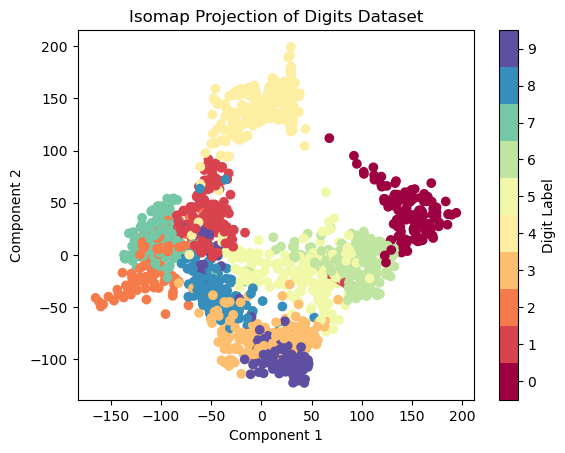

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=digits.target, cmap=plt.cm.get_cmap('Spectral', 10))
plt.colorbar(ticks=range(10), label='Digit Label')
plt.clim(-0.5, 9.5)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('Isomap Projection of Digits Dataset')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


# Split the data into training and testing sets but using X instead of digits.data
X_train, X_test, y_train, y_test = train_test_split(X, digits.target, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=10000, solver='sag')
lr.fit(X_train, y_train)

LogisticRegression(max_iter=10000, solver='sag')

In [5]:
# Predict on train set

from sklearn.metrics import confusion_matrix

y_pred = lr.predict(X_train)
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[141   0   0   0   0   0   4   0   0   0]
 [  0 113   2   0   4   1  21   9   4   0]
 [  0   4  63   0   0   0   0  73   4   0]
 [  0   0   0 103   0   5   0   0  15  26]
 [  0   5   1   0 129   0   0   0   0   0]
 [  1  11   0   3   0  90  27   0   3   0]
 [  5   7   0   0   0  15 119   0   0   0]
 [  0   2  55   0   0   0   0  84   4   0]
 [  0   3   4   4   0   2   0   0 128   3]
 [  0  10   5 110   0   0   0   6   7   2]]


In [6]:
from sklearn.metrics import accuracy_score

y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 68.61%


In [7]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  5  2  0  0]
 [ 0  1 13  0  0  0  0 17  2  0]
 [ 0  0  0 25  0  1  0  0  4  4]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 1  7  0  1  0 29  8  0  1  0]
 [ 2  0  0  0  0  3 30  0  0  0]
 [ 0  1 11  0  0  0  0 21  1  0]
 [ 0  0  0  0  0  0  0  0 28  2]
 [ 0  3  1 32  0  0  0  3  0  1]]
